## Imports et chargement des données

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from huggingface_hub import hf_hub_download


TRAIN_PATH = "StarLightCurves_TRAIN.txt"

TEST_PATH= "StarLightCurves_TEST.txt"

StarLightCurves_TEST="StarLightCurves_TEST.txt"
StarLightCurves_TRAIN="StarLightCurves_TRAIN.txt"
N=1000

def load_file(ffilename):
    file_path = hf_hub_download(
    repo_id="TheoSG/Classification_signal",
    filename= ffilename,
    repo_type="dataset"
    )
    data = np.loadtxt(file_path)


    X = data[:N, 1:]
    y  = data[:N, 0].astype(int)

    return X, 0, y

train_data=load_file(TRAIN_PATH)

test_data=load_file(TEST_PATH)

print(train_data[0].shape)
print(test_data[0].shape)
print(train_data[2].shape)
print(test_data[2].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


StarLightCurves_TRAIN.txt:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

StarLightCurves_TEST.txt:   0%|          | 0.00/135M [00:00<?, ?B/s]

(1000, 1024)
(1000, 1024)
(1000,)
(1000,)


## Dataloaders

In [2]:

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

In [3]:
class BasicDataset(Dataset):
    def __init__(self, signals, labels, transform=None):
        self.signals = signals
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        x = self.signals[idx]
        y = self.labels[idx]

        x = torch.tensor(x, dtype=torch.float32)
        x = x.unsqueeze(0)

        return x, torch.tensor(y, dtype=torch.long)



In [4]:
X, _, y = load_file(TRAIN_PATH)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    stratify=y,
    random_state=42
)


X_test, _, y_test = load_file(TEST_PATH)


In [5]:
print("Shape X :", X_train.shape)
print("Shape y :", y_train.shape)
print("Classes :", np.unique(y_train))


Shape X : (900, 1024)
Shape y : (900,)
Classes : [1 2 3]


In [6]:
train_dataset = BasicDataset(X_train, y_train)
val_dataset   = BasicDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

test_dataset = BasicDataset(X_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Pipeline

### Modèle

In [7]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1   = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.skip = None
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.skip is not None:
            identity = self.skip(identity)
        out += identity
        return F.relu(out)


class ResNet1D_SegmentClassifier(nn.Module):
    def __init__(self, n_segments=16, emb_dim=128, n_classes=6,recovering=20,input_dim=1024):
        super().__init__()

        self.n_segments = n_segments
        self.segment_length = input_dim // n_segments
        self.recovering=self.segment_length //recovering

        # Encodeur de segments
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3)
        self.bn1   = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)


        self.block1 = ResidualBlock1D(64, 64)
        self.block2 = ResidualBlock1D(64, 128, stride=2)
        self.block3 = ResidualBlock1D(128, emb_dim)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(emb_dim, n_classes)

    def encode_segment(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x).squeeze(-1)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x):
        B = x.size(0)
        embeddings = []

        for i in range(2*self.n_segments):
          for k in range(self.recovering):
            if (i+1) * self.segment_length + self.segment_length//2<len(x[0][0]):
              if i % self.recovering == k:
                start = i * self.segment_length + k*self.segment_length//self.recovering
                end = start + self.segment_length
                seg = x[:, :, start:end]
                z = self.encode_segment(seg)
                embeddings.append(z)


        Z = torch.stack(embeddings, dim=1)

        Z_global = Z.mean(dim=1) #prends en compte l'angle et la magnitude

        logits = self.fc(Z_global) #convertit l'embedding dim en classe dim

        return logits

cuda


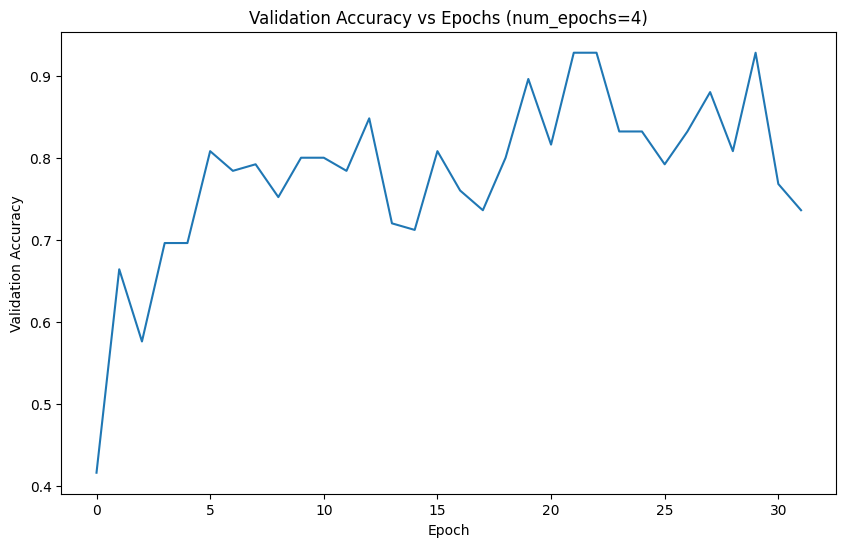

mean =  0.779
max =  0.928
min =  0.416
std =  0.10033444074693397


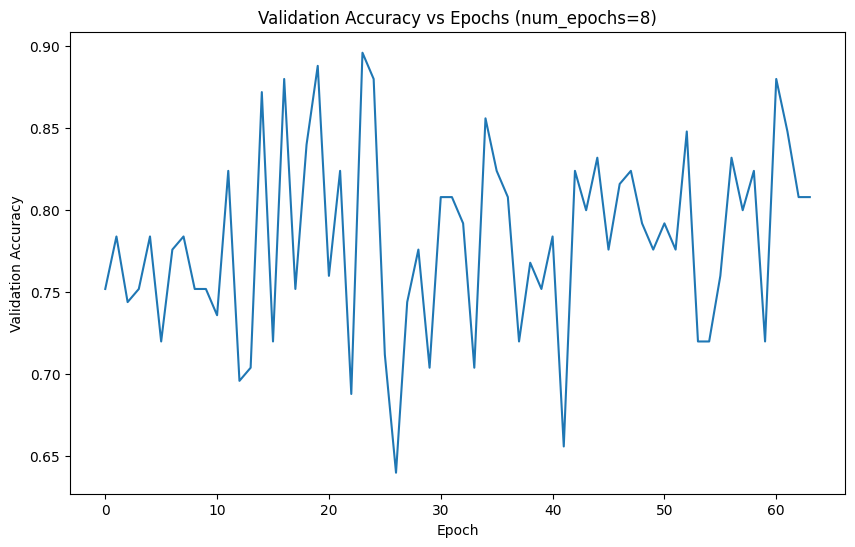

mean =  0.781125
max =  0.896
min =  0.64
std =  0.05727769526613305


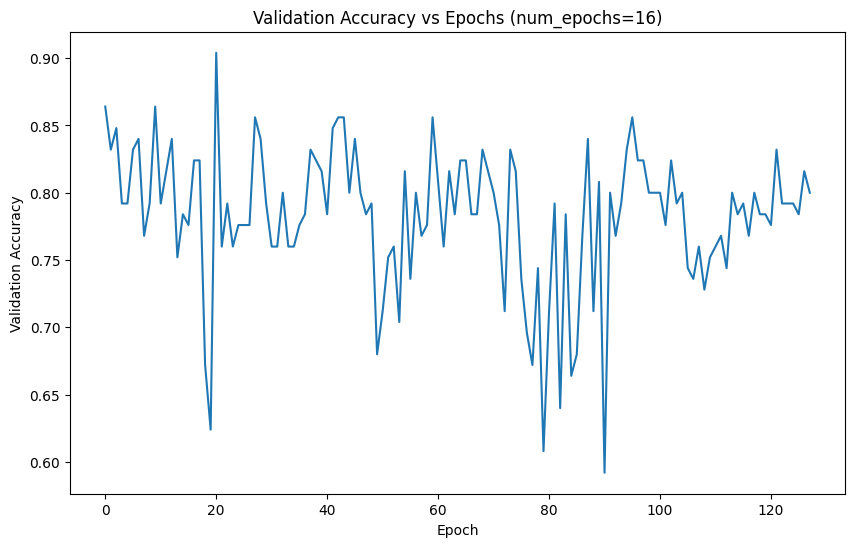

mean =  0.782375
max =  0.904
min =  0.592
std =  0.05259619163969954


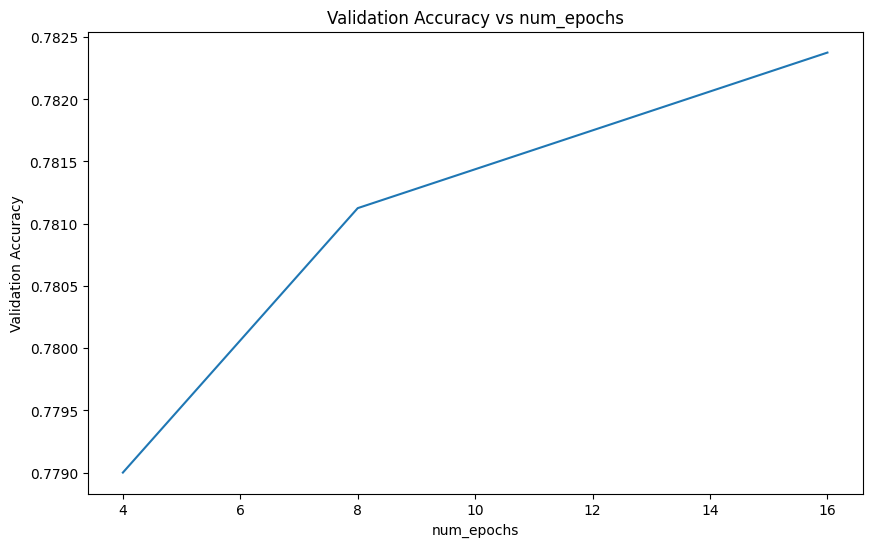

Modèle sauvegardé dans models/resnet_8_segments.pth


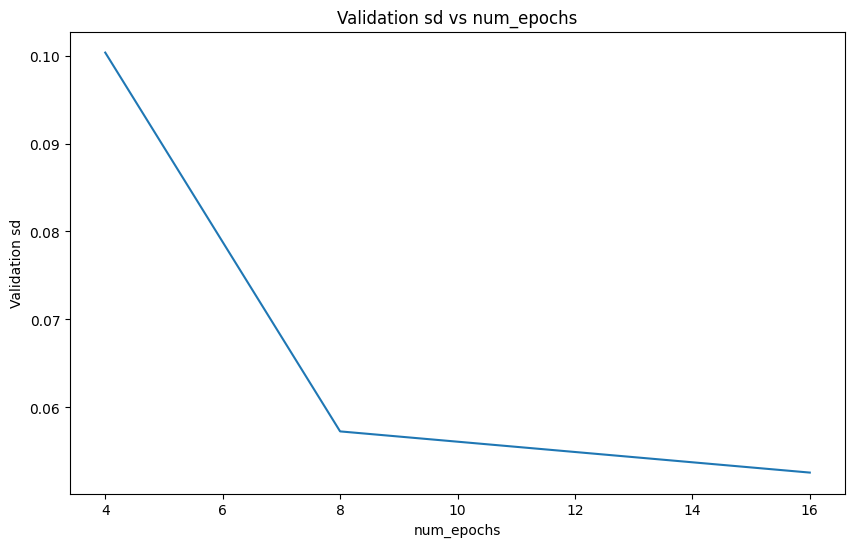

In [13]:
import os




device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


#n_segments_list = [2,4,8,16]
n_segments_list = [8]
for n_segments in n_segments_list:
  model = ResNet1D_SegmentClassifier(n_segments=n_segments)
  model.to(device) # Move the model to the specified device

  save_path = f"models/resnet_{n_segments}_segments.pth"

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


  from sklearn.model_selection import KFold, StratifiedKFold
  from tqdm import tqdm

  #n_split_list=[2,4,8,16,32]
  n_split_list=[8]

  for n_splits_ in n_split_list:

    kfold = StratifiedKFold(n_splits=n_splits_, shuffle=True, random_state=42)

    num_epochs_list = [2,4,8,16,32]
    num_epochs_list = [4,8,16]
    M=[]
    S=[]
    for num_epochs in num_epochs_list:
      val=[]


      for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        train_dataset = BasicDataset(X_train, y_train)
        val_dataset   = BasicDataset(X_val, y_val)

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)





        for epoch in range(num_epochs):
            model.train()
            train_loss = 0
            train_correct = 0
            total = 0

            for xb, yb in train_loader :

                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()

                logits = model(xb)
                loss = criterion(logits, yb)

                loss.backward()
                optimizer.step()

                train_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1) #on crée une sorte de proba
                train_correct += (preds == yb).sum().item()
                total += yb.size(0)

            train_acc = train_correct / total
            train_loss = train_loss / total

            # Validation
            model.eval()
            val_loss = 0
            val_correct = 0
            total_val = 0


            with torch.no_grad():
                for xb, yb in val_loader :
                    xb, yb = xb.to(device), yb.to(device)

                    logits = model(xb)
                    loss = criterion(logits, yb)

                    val_loss += loss.item() * xb.size(0)
                    preds = logits.argmax(dim=1)
                    val_correct += (preds == yb).sum().item()
                    total_val += yb.size(0)

            val_acc = val_correct / total_val
            val_loss = val_loss / total_val
            val.append(val_acc)


      import matplotlib.pyplot as plt
      plt.figure(figsize=(10, 6))
      plt.plot([i for i in range(len(val))],val)
      plt.xlabel('Epoch')
      plt.ylabel('Validation Accuracy')
      plt.title(f'Validation Accuracy vs Epochs (num_epochs={num_epochs})')
      plt.show()
      M.append(sum(val)/len(val))
      print("mean = ", sum(val)/len(val))
      print("max = ", max(val))
      print("min = ", min(val))
      print("std = ", np.std(val))
      S.append(np.std(val))

    plt.figure(figsize=(10, 6))
    plt.plot(num_epochs_list,M)
    plt.xlabel('num_epochs')
    plt.ylabel('Validation Accuracy')
    plt.title(f'Validation Accuracy vs num_epochs')
    plt.show()
    plt.figure(figsize=(10, 6))
    plt.plot(num_epochs_list,S)
    plt.xlabel('num_epochs')
    plt.ylabel('Validation sd')
    plt.title(f'Validation sd vs num_epochs')
  # Create the directory if it doesn't exist
  os.makedirs(os.path.dirname(save_path), exist_ok=True)
  torch.save(model.state_dict(), save_path)
  print(f"Modèle sauvegardé dans {save_path}")

## Résultats

In [9]:
n_segments=8
model = ResNet1D_SegmentClassifier(n_segments=n_segments)
save_path = f"models/resnet_{n_segments}_segments.pth"
model.load_state_dict(torch.load(save_path, map_location="cpu"))
model.eval()

ResNet1D_SegmentClassifier(
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (block1): ResidualBlock1D(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): ResidualBlock1D(
    (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [10]:
model.eval()
test_loss = 0
test_correct = 0
total_test = 0
pred_list=[]

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Test]"):
        # Move inputs to CPU to match the model's device as loaded in the previous cell
        xb, yb = xb.to("cpu"), yb.to("cpu")

        logits = model(xb)
        loss = criterion(logits, yb)

        test_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        pred_list.append(preds)
        test_correct += (preds == yb).sum().item()
        total_test += yb.size(0)

test_acc = test_correct / total_test
test_loss = test_loss / total_test

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}\n")

Epoch 16/16 [Test]: 100%|██████████| 16/16 [00:00<00:00, 17.95it/s]

Test Loss: 0.5096 | Test Acc: 0.864



In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

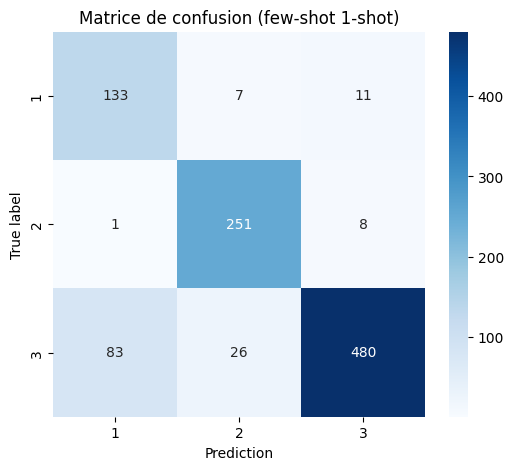

In [12]:
preds=torch.cat(pred_list,dim=0)
preds = preds.cpu()
true = y_test # y_test is already a numpy array, so .cpu() is not needed and would cause an error

cm = confusion_matrix(y_test, preds, labels=np.unique(y_train))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_train),
            yticklabels=np.unique(y_train))

plt.ylabel("True label")
plt.xlabel("Prediction")
plt.title("Matrice de confusion (few-shot 1-shot)")
plt.show()